In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)

ModuleNotFoundError: No module named 'numpy'

In [2]:
# ORNSTEIN-UHLENBECK PARAMETERS
# Mean growth rate (hour^-1)
mu = 1.0
# Doubling time at mean growth rate: T_d = ln(2) / mu
T_d = np.log(2) / mu
# Correlation timescale: "a couple of cell doublings" ≈ 2 * T_d
tau = 2 * T_d 
# Mean reversion rate: θ = 1/τ
theta = 1 / tau
# For OU process: fluctuation_scale = σ / sqrt(2θ)
# Therefore: σ = fluctuation_scale * sqrt(2θ)
fluctuation_scale = 0.2  # per hour
sigma = fluctuation_scale * np.sqrt(2 * theta)
print(f"Ornstein-Uhlenbeck parameters:")
print(f"Doubling time at μ = {mu} hour⁻¹: {T_d:.3f} hours")
print(f"τ: {tau:.3f} hours")
print(f"θ: {theta:.3f} hour⁻¹")
print(f"σ: {sigma:.3f} hour⁻¹/²")

Ornstein-Uhlenbeck parameters:
Doubling time at μ = 1.0 hour⁻¹: 0.693 hours
τ: 1.386 hours
θ: 0.721 hour⁻¹
σ: 0.240 hour⁻¹/²


In [3]:
# Time step
dt_minutes = 3  #minutes
dt = dt_minutes / 60  #hours
T_total = 5.0 #Total time (hours)
t = np.arange(0, T_total, dt)
n_points = len(t)
print(f"Δt: {dt_minutes} minutes = {dt:.4f} hours")
print(f"Total simulation time: {T_total} hours")
print(f"Number of time points: {n_points}")

Δt: 3 minutes = 0.0500 hours
Total simulation time: 5.0 hours
Number of time points: 100


In [ ]:
# Euler-Maruyama simulation of OU process
g = np.zeros(n_points)
g[0] = mu + 0.1 * np.random.randn() #starting with small random perturbation around mu
#intializie from stationary distribution M
stochastic_mean = 0
stochastic_var = dt * sigma**2
stochastic_sd = np.sqrt(stochastic_var) 
for i in range(n_points-1):
    stochasticity = np.random.normal(stochastic_mean, stochastic_sd)
    deterministic = theta*(mu - g[i])*dt
    g[i+1] = g[i] + deterministic + stochasticity
    # dg = θ(μ - g)dt + σ√dt dW
    # g_{i+1} = g_i + θ(μ - g_i)Δt + σ√Δt * ξ_i
print(f"  Mean: {np.mean(g):.4f} hour⁻¹ (target: {mu})")
print(f"  Std: {np.std(g):.4f} hour⁻¹ (target: ~{fluctuation_scale})")
print(f"  Range: [{np.min(g):.4f}, {np.max(g):.4f}] hour⁻¹")

  Mean: 0.8776 hour⁻¹ (target: 1.0)
  Std: 0.1511 hour⁻¹ (target: ~0.2)
  Range: [0.6186, 1.2321] hour⁻¹


In [5]:
#Another way to simulate OU process using discrete-time formulation
x = np.zeros(n_points)
x[0] = mu + 0.1 * np.random.randn() #starting with small random perturbation around mu
alpha = np.exp(-theta * dt)
beta = sigma * np.sqrt((1 - np.exp(-2 * theta * dt)) / (2 * theta))
for i in range(n_points-1):
    x_current = x[i]
    discrete_time_mean = x_current * alpha + mu * (1 - alpha)
    discrete_time_sd = beta
    x[i+1] = np.random.normal(discrete_time_mean, discrete_time_sd)
print(f"  Mean: {np.mean(x):.4f} hour⁻¹ (target: {mu})")
print(f"  Std: {np.std(x):.4f} hour⁻¹ (target: ~{fluctuation_scale})")
print(f"  Range: [{np.min(x):.4f}, {np.max(x):.4f}] hour⁻¹")

  Mean: 1.0216 hour⁻¹ (target: 1.0)
  Std: 0.1170 hour⁻¹ (target: ~0.2)
  Range: [0.7914, 1.3250] hour⁻¹


In [ ]:
# Initial cell area (pixels)
A0 = 250
A = np.zeros(n_points)
A[0] = A0
for i in range(n_points - 1):
    A[i + 1] = A[i] * np.exp(g[i] * dt)
print(f"  Initial: {A[0]:.2f} pixels")
print(f"  Final: {A[-1]:.2f} pixels")
print(f"  Growth factor: {A[-1]/A[0]:.2f}x")
print(f"  Equivalent doublings: {np.log2(A[-1]/A[0]):.2f}")
# Empirical average growth rate
g_empirical_avg = np.log(A[-1] / A[0]) / t[-1]
print(f"  Empirical avg growth: {g_empirical_avg:.4f} hour⁻¹")

  Initial: 250.00 pixels
  Final: 19233.40 pixels
  Growth factor: 76.93x
  Equivalent doublings: 6.27
  Empirical avg growth: 0.8774 hour⁻¹


A_{t+1} =A_{t}exp(g.delta t)

In [7]:
#Using discrete time method (x)
A0 = 250
A1 = np.zeros(n_points)
A1[0] = A0
for i in range(n_points - 1):
    A1[i + 1] = A1[i] * np.exp(x[i] * dt)
print(f"  Initial: {A1[0]:.2f} pixels")
print(f"  Final: {A1[-1]:.2f} pixels")
print(f"  Growth factor: {A1[-1]/A1[0]:.2f}x")
print(f"  Equivalent doublings: {np.log2(A1[-1]/A1[0]):.2f}")
# Empirical average growth rate
g_empirical_avgx = np.log(A1[-1] / A1[0]) / t[-1]
print(f"  Empirical avg growth: {g_empirical_avgx:.4f} hour⁻¹")

  Initial: 250.00 pixels
  Final: 39373.28 pixels
  Growth factor: 157.49x
  Equivalent doublings: 7.30
  Empirical avg growth: 1.0221 hour⁻¹


In [8]:
# Noise level (10% multiplicative noise)
Noise = np.random.normal(0,0.1,n_points)
A_true = A*(1 + Noise)
# Ensure no negative areas (safety check, unlikely with 10% noise)
A_true = np.maximum(A_true, 200.0)
relative_errors = np.abs(A_true - A) / A
print(f"  Mean relative error: {np.mean(relative_errors):.4f}")
print(f"  Max relative error: {np.max(relative_errors):.4f}")

  Mean relative error: 0.0854
  Max relative error: 0.3853


In [9]:
#Using discrete time method (x) (A1)
Noise1 = np.random.normal(0,0.1,n_points)
A_true1 = A1*(1 + Noise1)
# Ensure no negative areas (safety check, unlikely with 10% noise)
A_true1 = np.maximum(A_true1, 200.0)
relative_errors1 = np.abs(A_true1 - A1) / A1
print(f"  Mean relative error: {np.mean(relative_errors1):.4f}")
print(f"  Max relative error: {np.max(relative_errors1):.4f}")

  Mean relative error: 0.0708
  Max relative error: 0.2190


In [10]:
# Formula: g_emp(t_i) ≈ (1/Δt) * log(Â_{i+1} / Â_i)
g_empirical = np.zeros(n_points)
g_empirical[:-1] = (1 / dt) * np.log(A_true[1:] / A_true[:-1])
g_empirical[-1] = g_empirical[-2] 
print(f"  Mean: {np.mean(g_empirical):.4f} hour⁻¹")
print(f"  Std: {np.std(g_empirical):.4f} hour⁻¹ (true std: {np.std(g):.4f})")
print(f"  Range: [{np.min(g_empirical):.4f}, {np.max(g_empirical):.4f}]")

  Mean: 0.8795 hour⁻¹
  Std: 3.2404 hour⁻¹ (true std: 0.1511)
  Range: [-7.4267, 7.4620]


In [11]:
#Using discrete time method (x) (A1)
x_empirical = np.zeros(n_points)
x_empirical[:-1] = (1 / dt) * np.log(A_true1[1:] / A_true1[:-1])
x_empirical[-1] = x_empirical[-2] 
print(f"  Mean: {np.mean(x_empirical):.4f} hour⁻¹")
print(f"  Std: {np.std(x_empirical):.4f} hour⁻¹ (true std: {np.std(x):.4f})")
print(f"  Range: [{np.min(x_empirical):.4f}, {np.max(x_empirical):.4f}]")

  Mean: 1.0885 hour⁻¹
  Std: 2.3745 hour⁻¹ (true std: 0.1170)
  Range: [-4.8928, 7.3235]


In [12]:
# Experimental dataset (what you'd have in real life)
experimental_data = pd.DataFrame({
    'time in hours': t,
    'time in minutes': t * 60,
    'Area with noise': A_true,
    'Area1 with noise': A_true1
})
# Full dataset with ground truth (for validation)
full_data = pd.DataFrame({
    'time in hours': t,
    'time in minutes': t * 60,
    'g_initial': g,
    'g_empirical': g_empirical,
    'Area with noise': A_true,
    'Area without noise': A,
    'x_initial': x,
    'x_empirical': x_empirical,
    'Area1 with noise': A_true1,
    'Area1 without noise': A1,
    
})
# Parameters dataset
parameters = pd.DataFrame([{
    'mu_mean_growth_rate': mu,
    'theta_mean_reversion': theta,
    'sigma_volatility': sigma,
    'dt_hours': dt,
    'dt_minutes': dt_minutes,
    'total_time_hours': T_total,
    'initial_area_pixels': A0,
    'noise_level': Noise,
    'n_timepoints': n_points,
    'random_seed': 42
}])

In [13]:
# Save each DataFrame as a CSV file (in the current directory)
experimental_data.to_csv('experimental_data.csv', index=False)
full_data.to_csv('full_data.csv', index=False)
parameters.to_csv('parameters.csv', index=False)

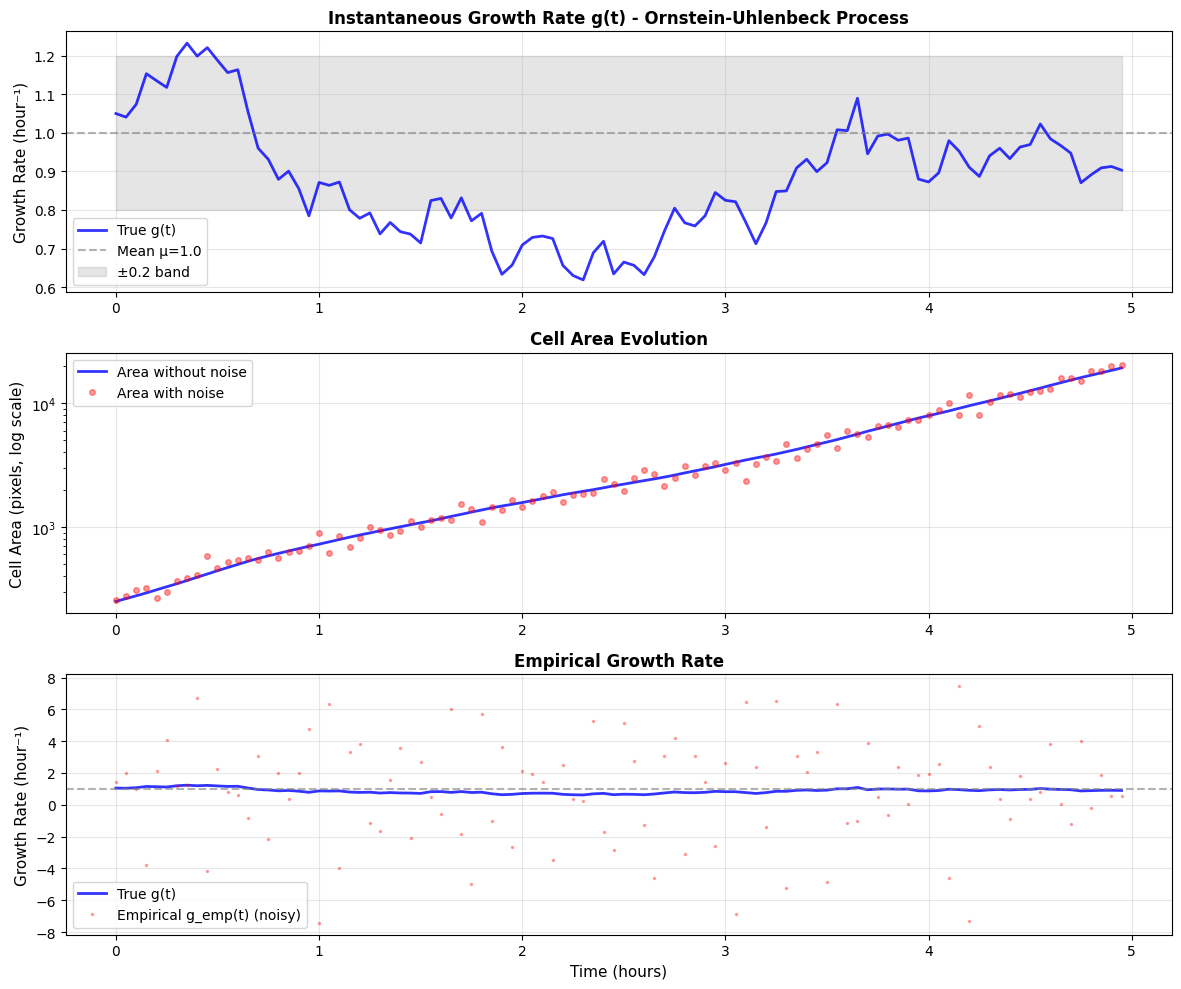

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
# Plot 1: Growth rate g(t)
axes[0].plot(t, g, 'b-', linewidth=2, label='True g(t)', alpha=0.8)
axes[0].axhline(mu, color='gray', linestyle='--', alpha=0.6, label=f'Mean μ={mu}')
axes[0].fill_between(t, mu - fluctuation_scale, mu + fluctuation_scale, 
                       color='gray', alpha=0.2, label=f'±{fluctuation_scale} band')
axes[0].set_ylabel('Growth Rate (hour⁻¹)', fontsize=11)
axes[0].set_title('Instantaneous Growth Rate g(t) - Ornstein-Uhlenbeck Process', fontsize=12, fontweight='bold')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)
# Plot 2: Cell area (log scale)
axes[1].semilogy(t, A, 'b-', linewidth=2, label='Area without noise', alpha=0.8)
axes[1].semilogy(t, A_true, 'ro', markersize=4, alpha=0.4, label='Area with noise')
axes[1].set_ylabel('Cell Area (pixels, log scale)', fontsize=11)
axes[1].set_title('Cell Area Evolution', fontsize=12, fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)
# Plot 3: True vs empirical growth rate
axes[2].plot(t, g, 'b-', linewidth=2, label='True g(t)', alpha=0.8)
axes[2].plot(t, g_empirical, 'r.', markersize=3, alpha=0.3, label='Empirical g_emp(t) (noisy)')
axes[2].axhline(mu, color='gray', linestyle='--', alpha=0.6)
axes[2].set_xlabel('Time (hours)', fontsize=11)
axes[2].set_ylabel('Growth Rate (hour⁻¹)', fontsize=11)
axes[2].set_title('Empirical Growth Rate', fontsize=12, fontweight='bold')
axes[2].legend(loc='best')
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bacterial_growth_simulation_using_Euler_Maruyama.png', dpi=150, bbox_inches='tight')
plt.show()

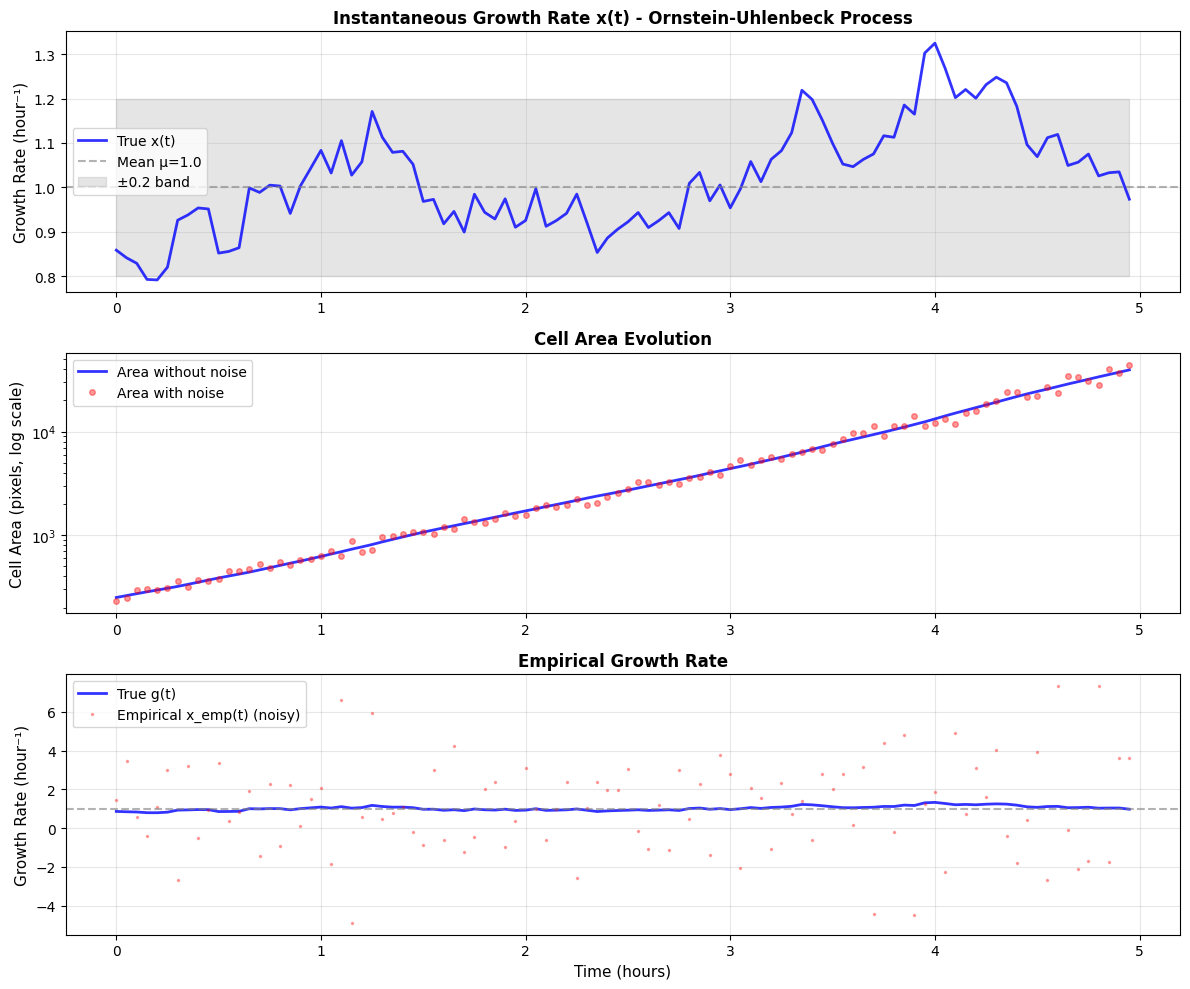

In [15]:
#Using discrete time method (x) (A1)
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
# Plot 1: Growth rate g(t)
axes[0].plot(t, x, 'b-', linewidth=2, label='True x(t)', alpha=0.8)
axes[0].axhline(mu, color='gray', linestyle='--', alpha=0.6, label=f'Mean μ={mu}')
axes[0].fill_between(t, mu - fluctuation_scale, mu + fluctuation_scale, 
                       color='gray', alpha=0.2, label=f'±{fluctuation_scale} band')
axes[0].set_ylabel('Growth Rate (hour⁻¹)', fontsize=11)
axes[0].set_title('Instantaneous Growth Rate x(t) - Ornstein-Uhlenbeck Process', fontsize=12, fontweight='bold')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)
# Plot 2: Cell area (log scale)
axes[1].semilogy(t, A1, 'b-', linewidth=2, label='Area without noise', alpha=0.8)
axes[1].semilogy(t, A_true1, 'ro', markersize=4, alpha=0.4, label='Area with noise')
axes[1].set_ylabel('Cell Area (pixels, log scale)', fontsize=11)
axes[1].set_title('Cell Area Evolution', fontsize=12, fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)
# Plot 3: True vs empirical growth rate
axes[2].plot(t, x, 'b-', linewidth=2, label='True g(t)', alpha=0.8)
axes[2].plot(t, x_empirical, 'r.', markersize=3, alpha=0.3, label='Empirical x_emp(t) (noisy)')
axes[2].axhline(mu, color='gray', linestyle='--', alpha=0.6)
axes[2].set_xlabel('Time (hours)', fontsize=11)
axes[2].set_ylabel('Growth Rate (hour⁻¹)', fontsize=11)
axes[2].set_title('Empirical Growth Rate', fontsize=12, fontweight='bold')
axes[2].legend(loc='best')
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bacterial_growth_simulation_using_discrete_time.png', dpi=150, bbox_inches='tight')
plt.show()

Meeting 2

$\mu = 1.0$ per hour $\\$
$\sigma = 0.240$ $\\$
$\alpha = e^{-\theta \Delta t}$
$\beta = \sigma \sqrt{\frac{1-e^{-2 \theta \Delta t}}{2\theta}}$ $\\$
$x_{t+\Delta t} \sim \mathcal{N}(x_{t}\alpha + \mu (1-\alpha),\beta^{2})$ 

In [36]:
#Another way to simulate OU process using discrete-time formulation
x = np.zeros(n_points)
x[0] = mu + 0.1 * np.random.randn() #starting with small random perturbation around mu
alpha = np.exp(-theta * dt)
beta = sigma * np.sqrt((1 - np.exp(-2 * theta * dt)) / (2 * theta))
for i in range(n_points-1):
    x_current = x[i]
    discrete_time_mean = x_current * alpha + mu * (1 - alpha)
    discrete_time_sd = beta
    x[i+1] = np.random.normal(discrete_time_mean, discrete_time_sd)
print(f"  Mean: {np.mean(x):.4f} hour⁻¹ (target: {mu})")
print(f"  Std: {np.std(x):.4f} hour⁻¹ (target: ~{fluctuation_scale})")
print(f"  Range: [{np.min(x):.4f}, {np.max(x):.4f}] hour⁻¹")

  Mean: 1.1781 hour⁻¹ (target: 1.0)
  Std: 0.1694 hour⁻¹ (target: ~0.2)
  Range: [0.8216, 1.4595] hour⁻¹


In [52]:
true_data = x
true_data

array([1.09980101, 0.94345471, 1.05564367, 1.04630754, 1.10313654,
       1.04461593, 1.07536631, 1.01711666, 0.9835993 , 1.08516752,
       1.07208979, 1.08100812, 1.12404454, 1.14580324, 1.14857454,
       1.16256723, 1.28361623, 1.27052915, 1.27155603, 1.31737038,
       1.36445688, 1.41417564, 1.43320398, 1.35755117, 1.43106738,
       1.35531401, 1.35869463, 1.30619123, 1.29196046, 1.29896385,
       1.30532845, 1.31677347, 1.39069375, 1.4007827 , 1.37370302,
       1.41133142, 1.45951842, 1.37846964, 1.39658221, 1.41952836,
       1.38896679, 1.44777216, 1.4239928 , 1.41559859, 1.3917446 ,
       1.37868914, 1.30743304, 1.22056302, 1.29687818, 1.24167438,
       1.18080575, 1.0607846 , 1.02491872, 0.95422774, 1.04248444,
       1.09425894, 1.05461198, 1.17151934, 1.21724277, 1.19240841,
       1.05371992, 1.17269055, 1.09325706, 1.0031397 , 1.05698086,
       1.18368741, 1.2502167 , 1.27110556, 1.29288188, 1.32753414,
       1.35597358, 1.35819941, 1.35100811, 1.33527125, 1.28361

In [53]:
#Adding noise to x
sigma_noise = 0.5
x_noisy = x + sigma_noise * np.random.randn(len(x))
x_noisy

array([0.57634552, 1.21178109, 1.64849574, 1.4057842 , 1.60116038,
       0.66621838, 0.36446098, 1.76778349, 0.82225938, 0.95975101,
       1.73618686, 1.35912313, 1.35198843, 2.22830441, 0.82681542,
       1.6264873 , 1.31212279, 1.40482529, 2.03579025, 1.57128826,
       1.63360492, 1.95042931, 1.25072762, 0.93794633, 0.90866278,
       0.37213571, 2.38679819, 0.75458704, 1.18133364, 1.1605572 ,
       1.4590318 , 1.72464207, 1.82093049, 1.10924398, 1.29014216,
       1.5526214 , 1.33517285, 2.18214243, 1.64206969, 1.78696725,
       1.72040742, 2.03450909, 1.51450358, 0.76718262, 1.59158858,
       1.05301069, 1.0431247 , 1.51374503, 1.91601971, 1.25231017,
       1.33522226, 1.91189207, 1.14529531, 2.25506929, 1.32523927,
       0.21387756, 1.43128279, 1.36209853, 1.86211915, 1.52899908,
       0.98449193, 0.56054143, 0.98874544, 0.57787947, 0.76671914,
       1.47797661, 2.08516895, 1.46844132, 0.69494034, 1.54983547,
       1.95428932, 1.05330796, 1.28399953, 1.34261535, 0.89116

In [54]:
# OU and filter parameters from your simulation
# mu, theta, sigma, dt must match those used in 'x'
alpha = np.exp(-theta * dt)
beta = sigma * np.sqrt((1 - np.exp(-2 * theta * dt)) / (2 * theta))
# Prepare arrays
x_filtered = np.zeros_like(x)         # Posterior mean estimate of state
P_filtered = np.zeros_like(x)         # Posterior variance
n_points = len(x)
# Initialize at t=0 (could also use mu and beta**2/(1-alpha**2) for more generality)
x_filtered[0] = x_noisy[0]            # Initial guess: first noisy observation
P_filtered[0] = 1.0                   # Large initial variance

# Run Kalman Filter
for i in range(1, n_points):
    # Predict
    x_pred = alpha * x_filtered[i-1] + (1 - alpha) * mu
    P_pred = alpha**2 * P_filtered[i-1] + beta**2

    # Update
    innovation = x_noisy[i] - x_pred
    S = P_pred + sigma_noise**2       # Innovation covariance
    K = P_pred / S                    # Kalman gain

    x_filtered[i] = x_pred + K * innovation
    P_filtered[i] = (1 - K) * P_pred
x_filtered

array([0.57634552, 1.08068885, 1.32145797, 1.33782218, 1.38622944,
       1.2474763 , 1.10794302, 1.19083527, 1.14168574, 1.11769177,
       1.17569475, 1.18734204, 1.19610785, 1.27914174, 1.23208948,
       1.25686982, 1.25294257, 1.25670779, 1.30919122, 1.31935621,
       1.33301985, 1.36918404, 1.34811468, 1.30573778, 1.26583331,
       1.19002822, 1.27346124, 1.22569007, 1.21497909, 1.20387109,
       1.21620998, 1.24700004, 1.28163691, 1.2595716 , 1.25333506,
       1.26729002, 1.26357372, 1.32322987, 1.33633441, 1.35880338,
       1.37391514, 1.41075133, 1.40499277, 1.34431281, 1.3513979 ,
       1.31770129, 1.2868795 , 1.29432999, 1.33087411, 1.31418616,
       1.30544632, 1.3404919 , 1.31482234, 1.37436278, 1.35843642,
       1.26163747, 1.26566296, 1.26411669, 1.29988915, 1.30707862,
       1.27303955, 1.21114512, 1.18769618, 1.13622997, 1.10430691,
       1.12865116, 1.19550438, 1.20937329, 1.16428358, 1.1875439 ,
       1.23836522, 1.21679834, 1.21468221, 1.21714802, 1.18580

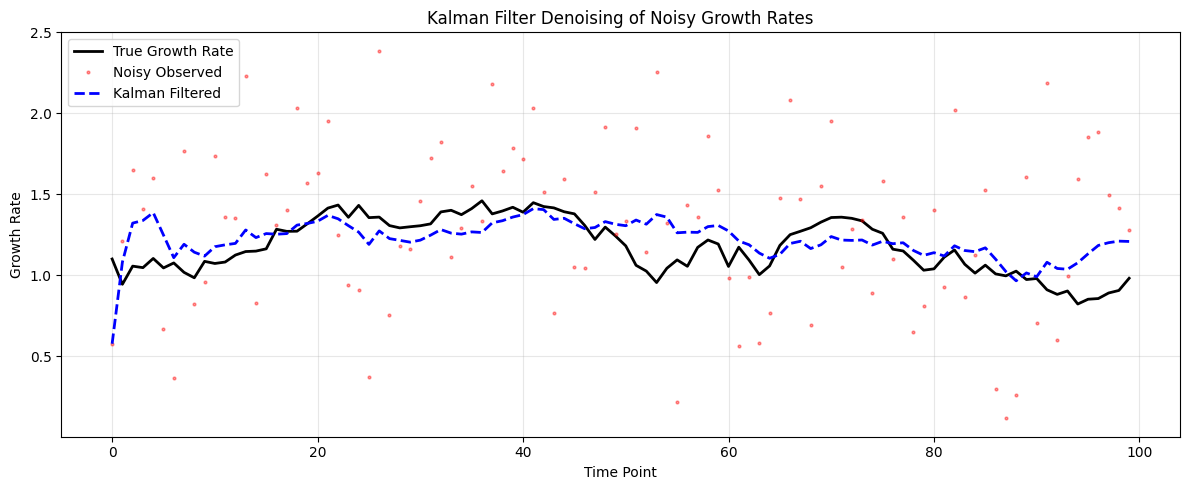

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(x, label='True Growth Rate', color='black', linewidth=2)
plt.plot(x_noisy, '.', label='Noisy Observed', alpha=0.4, color='red', markersize=4)
plt.plot(x_filtered, label='Kalman Filtered', color='blue', linewidth=2, linestyle='--')
plt.xlabel('Time Point')
plt.ylabel('Growth Rate')
plt.legend()
plt.title('Kalman Filter Denoising of Noisy Growth Rates')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [56]:
# RMSE between filtered and true growth rate
rmse_filtered = np.sqrt(np.mean((x_filtered - x) ** 2))
print(f"RMSE (filtered estimate vs. true): {rmse_filtered:.4f}")

# RMSE between noisy observed and true growth rate (for comparison)
rmse_noisy = np.sqrt(np.mean((x_noisy - x) ** 2))
print(f"RMSE (noisy observed vs. true): {rmse_noisy:.4f}")

RMSE (filtered estimate vs. true): 0.1530
RMSE (noisy observed vs. true): 0.5167


In [100]:
true_data = x
true_data

array([1.09980101, 0.94345471, 1.05564367, 1.04630754, 1.10313654,
       1.04461593, 1.07536631, 1.01711666, 0.9835993 , 1.08516752,
       1.07208979, 1.08100812, 1.12404454, 1.14580324, 1.14857454,
       1.16256723, 1.28361623, 1.27052915, 1.27155603, 1.31737038,
       1.36445688, 1.41417564, 1.43320398, 1.35755117, 1.43106738,
       1.35531401, 1.35869463, 1.30619123, 1.29196046, 1.29896385,
       1.30532845, 1.31677347, 1.39069375, 1.4007827 , 1.37370302,
       1.41133142, 1.45951842, 1.37846964, 1.39658221, 1.41952836,
       1.38896679, 1.44777216, 1.4239928 , 1.41559859, 1.3917446 ,
       1.37868914, 1.30743304, 1.22056302, 1.29687818, 1.24167438,
       1.18080575, 1.0607846 , 1.02491872, 0.95422774, 1.04248444,
       1.09425894, 1.05461198, 1.17151934, 1.21724277, 1.19240841,
       1.05371992, 1.17269055, 1.09325706, 1.0031397 , 1.05698086,
       1.18368741, 1.2502167 , 1.27110556, 1.29288188, 1.32753414,
       1.35597358, 1.35819941, 1.35100811, 1.33527125, 1.28361

In [101]:
x = true_data
alpha = np.exp(-theta * dt)
beta = sigma * np.sqrt((1 - np.exp(-2 * theta * dt)) / (2 * theta))
Difference = []
sigma_noise_list = []
rmse_filtered = 0
rmse_noisy = 0
for i in range(1,100):
    sigma_noise = 10-i*0.09999
    x_noisy = x + sigma_noise * np.random.randn(len(x))
    # Prepare arrays
    x_filtered = np.zeros_like(x)         # Posterior mean estimate of state
    P_filtered = np.zeros_like(x)         # Posterior variance
    n_points = len(x)
    # Initialize at t=0 (could also use mu and beta**2/(1-alpha**2) for more generality)
    x_filtered[0] = x_noisy[0]            # Initial guess: first noisy observation
    P_filtered[0] = 1.0                   # Large initial variance
    # Run Kalman Filter
    for i in range(1, n_points):
        # Predict
        x_pred = alpha * x_filtered[i-1] + (1 - alpha) * mu
        P_pred = alpha**2 * P_filtered[i-1] + beta**2
        # Update
        innovation = x_noisy[i] - x_pred
        S = P_pred + sigma_noise**2       # Innovation covariance
        K = P_pred / S                    # Kalman gain
        x_filtered[i] = x_pred + K * innovation
        P_filtered[i] = (1 - K) * P_pred
    # RMSE between filtered and true growth rate
    rmse_filtered = np.sqrt(np.mean((x_filtered - x) ** 2))
    # RMSE between noisy observed and true growth rate (for comparison)
    rmse_noisy = np.sqrt(np.mean((x_noisy - x) ** 2))
    Difference.append(rmse_noisy - rmse_filtered)
    sigma_noise_list.append(sigma_noise)

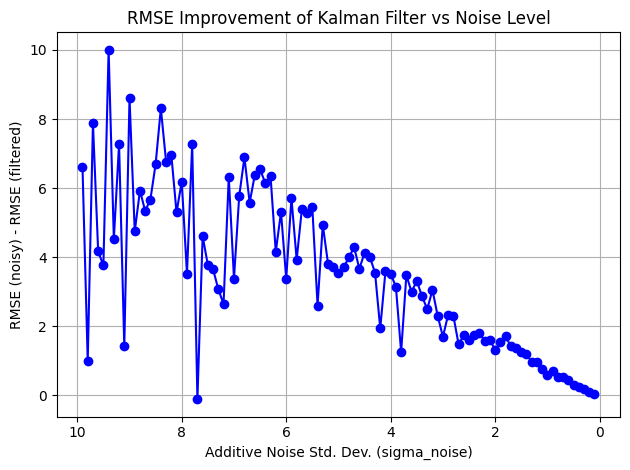

In [102]:
plt.plot(sigma_noise_list[::-1], Difference[::-1], marker='o', linestyle='-', color='blue')
plt.xlabel('Additive Noise Std. Dev. (sigma_noise)')
plt.ylabel('RMSE (noisy) - RMSE (filtered)')
plt.title('RMSE Improvement of Kalman Filter vs Noise Level')
plt.gca().invert_xaxis()
plt.grid(True)
plt.tight_layout()
plt.show()

In [103]:
sigma_noise_list1 = np.linspace(0, 0.5, 49)  # 50 steps from 0 to 0.5
x = true_data
alpha = np.exp(-theta * dt)
beta = sigma * np.sqrt((1 - np.exp(-2 * theta * dt)) / (2 * theta))
Difference1 = np.zeros(49)
rmse_filtered = 0
rmse_noisy = 0
for i in range(1,50):
    sigma_noise = sigma_noise_list1[i-1]
    x_noisy = x + sigma_noise * np.random.randn(len(x))
    # Prepare arrays
    x_filtered = np.zeros_like(x)         # Posterior mean estimate of state
    P_filtered = np.zeros_like(x)         # Posterior variance
    n_points = len(x)
    # Initialize at t=0 (could also use mu and beta**2/(1-alpha**2) for more generality)
    x_filtered[0] = x_noisy[0]            # Initial guess: first noisy observation
    P_filtered[0] = 1.0                   # Large initial variance
    # Run Kalman Filter
    for k in range(1, n_points):
        # Predict
        x_pred = alpha * x_filtered[k-1] + (1 - alpha) * mu
        P_pred = alpha**2 * P_filtered[k-1] + beta**2
        # Update
        innovation = x_noisy[k] - x_pred
        S = P_pred + sigma_noise**2       # Innovation covariance
        K = P_pred / S                    # Kalman gain
        x_filtered[k] = x_pred + K * innovation
        P_filtered[k] = (1 - K) * P_pred
    # RMSE between filtered and true growth rate
    rmse_filtered = np.sqrt(np.mean((x_filtered - x) ** 2))
    # RMSE between noisy observed and true growth rate (for comparison)
    rmse_noisy = np.sqrt(np.mean((x_noisy - x) ** 2))
    Difference1[i-1] = (rmse_noisy - rmse_filtered)

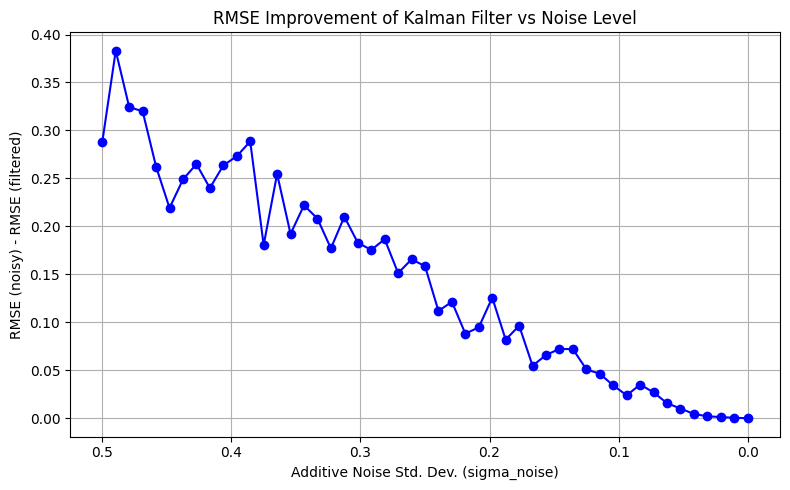

In [104]:
plt.figure(figsize=(8,5))
plt.plot(sigma_noise_list1[::-1], Difference1[::-1], marker='o', linestyle='-', color='blue')
plt.xlabel('Additive Noise Std. Dev. (sigma_noise)')
plt.ylabel('RMSE (noisy) - RMSE (filtered)')
plt.title('RMSE Improvement of Kalman Filter vs Noise Level')
plt.gca().invert_xaxis()
plt.grid(True)
plt.tight_layout()
plt.show()

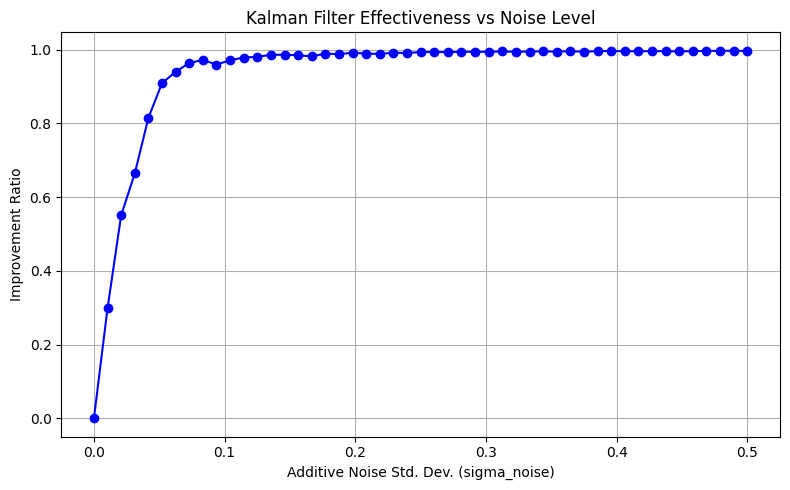

In [105]:
plt.figure(figsize=(8,5))
# Calculate improvement ratio
improvement_ratio = Difference1 / (Difference1 + 0.001)  # Avoid division by zero
plt.plot(sigma_noise_list1, improvement_ratio, marker='o', linestyle='-', color='blue')
plt.xlabel('Additive Noise Std. Dev. (sigma_noise)')
plt.ylabel('Improvement Ratio')
plt.title('Kalman Filter Effectiveness vs Noise Level')
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
import xarray as xr
import matplotlib.pyplot as plt

In [12]:
ds = xr.load_dataset("growth_rates.nc")

In [13]:
# View the dataset structure
print(ds)

<xarray.Dataset> Size: 49kB
Dimensions:             (smoothing: 5, frame: 1000)
Coordinates:
  * smoothing           (smoothing) int64 40B 3 5 7 9 11
  * frame               (frame) float64 8kB 0.0 0.004167 ... 4.158 4.162
Data variables:
    growth_rate_length  (smoothing, frame) float32 20kB 2.474 2.474 ... 0.7119
    growth_rate_area    (smoothing, frame) float32 20kB 0.2359 0.2359 ... 1.035
    division            (frame) bool 1kB False False False ... False False False


In [14]:
# Access variables
growth_rate_area = ds['growth_rate_area']
growth_rate_length = ds['growth_rate_length']

In [15]:
# Access coordinates
frames = ds['frame']
smoothing = ds['smoothing']

In [16]:
# Convert to pandas DataFrame (if needed)
df = ds.to_dataframe()

In [17]:
df

growth_rate_length  growth_rate_area  division
smoothing frame                                                   
3         0.000000            2.473697          0.235920     False
          0.004167            2.473697          0.235920     False
          0.008333            2.473697          0.588856     False
          0.012500           -0.719261          0.411644     False
          0.016667            5.486526          1.110821     False
...                                ...               ...       ...
11        4.145833            0.711877          1.034939     False
          4.150000            0.711877          1.034939     False
          4.154167            0.711877          1.034939     False
          4.158333            0.711877          1.034939     False
          4.162500            0.711877          1.034939     False

[5000 rows x 3 columns]

In [18]:
# Install openpyxl if not already installed (for Excel support)
import subprocess
subprocess.check_call(['pip', 'install', 'openpyxl'])

# Export dataframe to Excel
df.to_excel('growth_rates_data.xlsx', index=False, sheet_name='Data')

print("✓ Excel file saved: growth_rates_data.xlsx")

✓ Excel file saved: growth_rates_data.xlsx


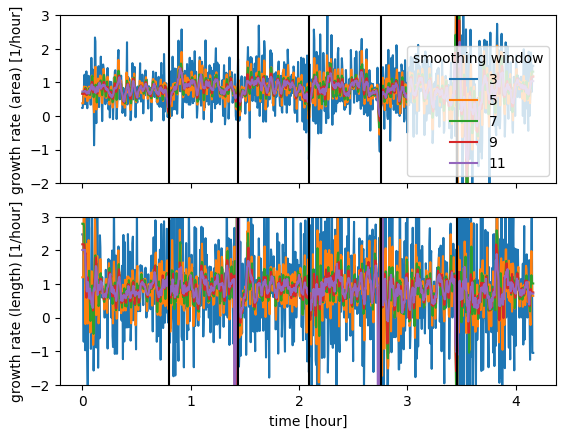

In [19]:
fig, axs = plt.subplots(2, 1, sharex=True)

for smoothing in ds.smoothing.values:
    axs[0].plot(ds.frame, ds.growth_rate_area.sel(smoothing=smoothing), label=smoothing)
    axs[1].plot(
        ds.frame, ds.growth_rate_length.sel(smoothing=smoothing), label=smoothing
    )

for division in ds.division:
    if division:
        axs[0].axvline(division.frame, color="black")
        axs[1].axvline(division.frame, color="black")

axs[1].set_xlabel("time [hour]")
axs[0].set_ylabel("growth rate (area) [1/hour]")
axs[1].set_ylabel("growth rate (length) [1/hour]")

axs[0].set_ylim(-2, 3)
axs[1].set_ylim(-2, 3)

axs[0].legend(title="smoothing window")
plt.show()

In [13]:
import xarray as xr
import numpy as np
ds = xr.open_dataset("growth_rates.nc")

# Get frame values (time in hours)
frames = ds['frame'].values
print(f"First frame: {frames[0]}")
print(f"Last frame: {frames[-1]}")
print(f"Total frames: {len(frames)}")

# Calculate time difference between consecutive frames
time_diffs = np.diff(frames)
print(f"\nTime difference between frames:")
print(f"  Min: {np.min(time_diffs):.6f} hours")
print(f"  Max: {np.max(time_diffs):.6f} hours")
print(f"  Mean: {np.mean(time_diffs):.6f} hours")
print(f"  Unique values: {np.unique(time_diffs)}")

# Convert to minutes for readability
print(f"\nMean time step: {np.mean(time_diffs) * 60:.2f} minutes")

First frame: 0.0
Last frame: 4.1625
Total frames: 1000

Time difference between frames:
  Min: 0.004167 hours
  Max: 0.004167 hours
  Mean: 0.004167 hours
  Unique values: [0.00416667 0.00416667 0.00416667 0.00416667 0.00416667 0.00416667
 0.00416667 0.00416667 0.00416667 0.00416667 0.00416667 0.00416667]

Mean time step: 0.25 minutes


In [ ]:
# make EXCEL to 
FRAME ! DIVISION ! GR AREAS (5) ! GR LENGTH (5) ! TRUE RATES
#apply kf for GR(A) with 3 smoothing.

SyntaxError: invalid syntax (2004571912.py, line 2)

In [ ]:
#ACF for growth rates after filtering

In [1]:
import xarray as xr

ds = xr.open_dataset("growth_rates.nc")
print(ds)

<xarray.Dataset> Size: 49kB
Dimensions:             (smoothing: 5, frame: 1000)
Coordinates:
  * smoothing           (smoothing) int64 40B 3 5 7 9 11
  * frame               (frame) float64 8kB 0.0 0.004167 ... 4.158 4.162
Data variables:
    growth_rate_length  (smoothing, frame) float32 20kB ...
    growth_rate_area    (smoothing, frame) float32 20kB ...
    division            (frame) bool 1kB ...


In [2]:
# growth_rate_area for smoothing = 3
g_area_3 = ds['growth_rate_area'].sel(smoothing=3)      # DataArray with dim 'frame'
g_area_3_list = g_area_3.values.tolist()                # Python list if you need it

# growth_rate_area for smoothing = 7
g_area_7 = ds['growth_rate_area'].sel(smoothing=7)
g_area_7_list = g_area_7.values.tolist()

In [13]:
# growth_rate_length for smoothing = 3
g_length_3 = ds['growth_rate_length'].sel(smoothing=3)      # DataArray with dim 'frame'
g_length_3_list = g_length_3.values.tolist()                # Python list if you need it

# growth_rate_area for smoothing = 7
g_length_7 = ds['growth_rate_length'].sel(smoothing=7)
g_length_7_list = g_length_7.values.tolist()

In [16]:
import numpy as np
#Without considering other parameters like theta, mu; a random walk 
y = g_area_3_list
N = len(y)

r = 0.5**2    # measurement noise variance
q = 0.5      # process noise variance, tune this

g_filt = np.zeros(N)
P_filt = np.zeros(N)

g_filt[0] = y[0]
P_filt[0] = 1.0

for i in range(1, N):
    # Predict
    g_pred = g_filt[i-1]
    P_pred = P_filt[i-1] + q

    # Update
    v = y[i] - g_pred
    S = P_pred + r
    K = P_pred / S

    g_filt[i] = g_pred + K * v
    P_filt[i] = (1 - K) * P_pred


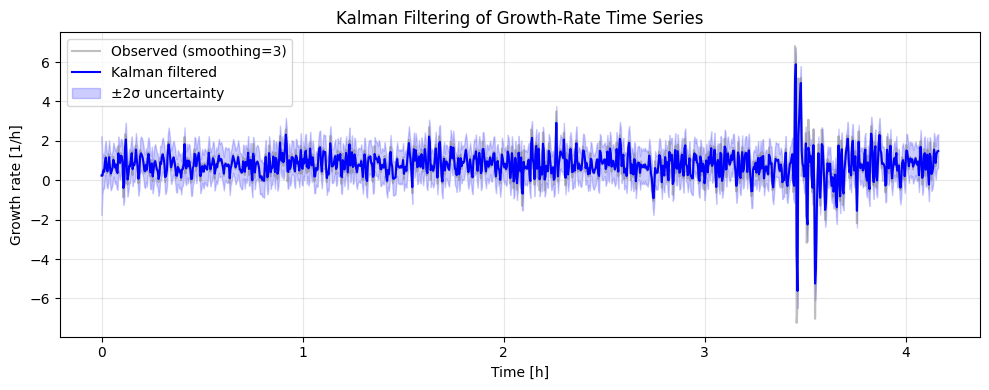

In [17]:
import matplotlib.pyplot as plt
# 1σ uncertainty band (optional)
g_std = np.sqrt(P_filt)
time = ds['frame'].values
plt.figure(figsize=(10, 4))

# raw observations
plt.plot(time, y, color='gray', alpha=0.5, label='Observed (smoothing=3)')

# filtered estimate
plt.plot(time, g_filt, color='blue', label='Kalman filtered')

# uncertainty band
plt.fill_between(time,
                 g_filt - 2*g_std,
                 g_filt + 2*g_std,
                 color='blue', alpha=0.2, label='±2σ uncertainty')

plt.xlabel('Time [h]')
plt.ylabel('Growth rate [1/h]')
plt.title('Kalman Filtering of Growth-Rate Time Series')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [64]:
#OU process-based Kalman filter
sigma_n = 0.0015       
y = g_area_3_list
N = len(y)
dt = np.mean(np.diff(time))
mu = np.mean(y)      # long-term mean
theta = 1.0          # mean-reversion rate [1/h]
sigma = 0.5          # OU variance
alpha = np.exp(-theta * dt)
beta2 = (sigma**2 / (2 * theta)) * (1 - np.exp(-2 * theta * dt))

# Arrays for filtered state and variance
g_filt = np.zeros(N)
P_filt = np.zeros(N)
g_filt[0] = y[0]    # or mu
P_filt[0] = 1.0

for i in range(1, N):
    # Predict
    g_pred = alpha * g_filt[i-1] + (1 - alpha) * mu
    P_pred = alpha**2 * P_filt[i-1] + beta2

    # Update
    v = y[i] - g_pred                 # innovation
    S = P_pred + sigma_n**2           # innovation variance
    K = P_pred / S                    # Kalman gain

    g_filt[i] = g_pred + K * v        # posterior mean
    P_filt[i] = (1 - K) * P_pred      # posterior variance

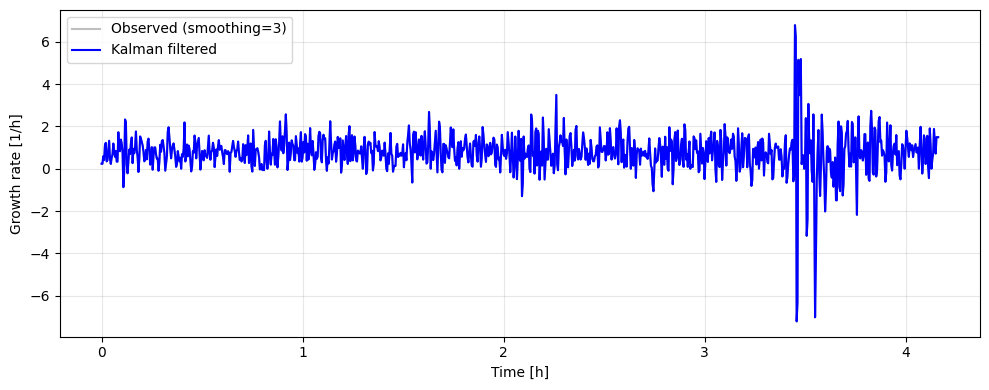

In [65]:
plt.figure(figsize=(10,4))
plt.plot(time, y, color='gray', alpha=0.5, label='Observed (smoothing=3)')
plt.plot(time, g_filt, color='blue', label='Kalman filtered')
plt.xlabel('Time [h]')
plt.ylabel('Growth rate [1/h]')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


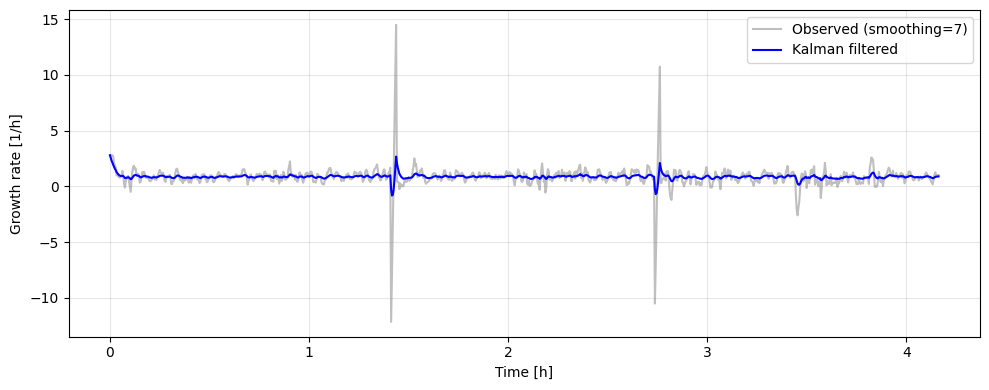

In [68]:
#for growth rate computed using length measurements
#OU process-based Kalman filter
sigma_n =  1.0      
y = g_length_7_list
N = len(y)
dt = 0.25
mu = np.mean(y)      # long-term mean
theta = 1.0          # mean-reversion rate [1/h]
sigma = 0.5          # OU variance
alpha = np.exp(-theta * dt)
beta2 = (sigma**2 / (2 * theta)) * (1 - np.exp(-2 * theta * dt))

# Arrays for filtered state and variance
g_filt = np.zeros(N)
P_filt = np.zeros(N)
g_filt[0] = y[0]    # or mu
P_filt[0] = 1.0

for i in range(1, N):
    # Predict
    g_pred = alpha * g_filt[i-1] + (1 - alpha) * mu
    P_pred = alpha**2 * P_filt[i-1] + beta2

    # Update
    v = y[i] - g_pred                 # innovation
    S = P_pred + sigma_n**2           # innovation variance
    K = P_pred / S                    # Kalman gain

    g_filt[i] = g_pred + K * v        # posterior mean
    P_filt[i] = (1 - K) * P_pred      # posterior variance
plt.figure(figsize=(10,4))
plt.plot(time, y, color='gray', alpha=0.5, label='Observed (smoothing=7)')
plt.plot(time, g_filt, color='blue', label='Kalman filtered')
plt.xlabel('Time [h]')
plt.ylabel('Growth rate [1/h]')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


First Estimating Parameters from data: \
$y_{i}$, $\Delta t$ given \
Unknown stuff: $\mu$, $\theta$, $\sigma$, $\sigma_{n}$ 
1. $\hat{\mu} = \frac{1}{N} \sum y_{i}$ \
$z_{i}=y_{i}-\hat{\mu}$ 
2. Sample Variance: $\hat{Var(y)} = \frac{1}{N-1}\sigma z_{i}^{2}$ 
3. Lag 1 Covariance: $\hat{Cov_{1}} = \frac{1}{N-1}z_{i}z_{i+1}$ 
4. Sample Lag 1 AC: $\hat{\rho_{1}} = \frac{\hat{Cov_{1}}}{\hat{Var(y)}}$ \
as $\rho_{1} \approx e^{-\theta \Delta t}$ 
5. $\hat{\theta}= - \frac{1}{\Delta t} \log \hat{\rho_{1}}$ \
$Var(g) = \frac{\sigma^{2}}{2 \theta} \implies Var(y) = Var(g) + \sigma^{2}_{n} = \frac{\sigma^{2}}{2 \theta} + \sigma^{2}_{n}$ \
$Cov(y_{i},y_{i+1}) = Cov(g_{i},g_{i+1}) = e^{-\theta \Delta t}Var(g) = \alpha  \frac{\sigma^{2}}{2 \theta}$ \
$\hat{Cov_{1}} \approx \alpha  \frac{\sigma^{2}}{2 \theta}$ 
6. $\hat{\sigma^{2}}= 2 \hat{\theta} \frac{\hat{Cov_{1}}}{e^{-\theta \Delta t}}$ 
7. $\hat{\sigma_{n}^{2}}= \hat{Var(y)} - \frac{\hat{\sigma^{2}}}{2 \hat{\theta}}$

In [54]:
y = g_area_7_list
N = len(y)
dt = 0.249
mu_hat = np.mean(y)
z = y - mu_hat
var_y = np.sum(z**2) / (N - 1)
cov1 = np.sum(z[:-1] * z[1:]) / (N - 1)
rho1 = cov1 / var_y
rho1 = np.clip(rho1, -0.9999, 0.9999)
theta_hat = -np.log(rho1) / dt
alpha_hat = np.exp(-theta_hat * dt)
var_g = cov1 / alpha_hat
sigma2_hat = 2.0 * theta_hat * var_g
sigma_n2_hat = var_y - sigma2_hat/(2.0 * theta_hat)

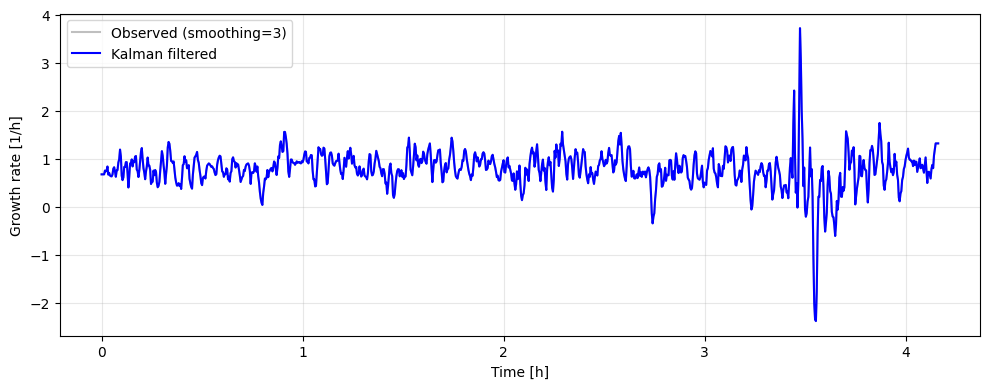

In [55]:
#OU process-based Kalman filter
# Observations
y = g_area_7_list
N = len(y)
std = np.std(y)
sigma_n = np.sqrt(sigma_n2_hat)       
mu = mu_hat     
theta = theta_hat         
sigma2 = sigma2_hat       
alpha = np.exp(-theta_hat * dt)
beta2 = (sigma2 / (2 * theta_hat)) * (1 - np.exp(-2 * theta_hat * dt))
g_filt = np.zeros(N)
P_filt = np.zeros(N)
g_filt[0] = y[0]    # or mu
P_filt[0] = 1.0

for i in range(1, N):
    g_pred = alpha * g_filt[i-1] + (1 - alpha) * mu
    P_pred = alpha**2 * P_filt[i-1] + beta2

    v = y[i] - g_pred                 # innovation
    S = P_pred + sigma_n**2           # innovation variance
    K = P_pred / S                    # Kalman gain

    g_filt[i] = g_pred + K * v        # posterior mean
    P_filt[i] = (1 - K) * P_pred      # posterior variance
plt.figure(figsize=(10,4))
plt.plot(time, y, color='gray', alpha=0.5, label='Observed (smoothing=3)')
plt.plot(time, g_filt, color='blue', label='Kalman filtered')
plt.xlabel('Time [h]')
plt.ylabel('Growth rate [1/h]')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [29]:
import numpy as np

def kalman_filter_ou(y, dt, mu, theta, sigma, sigma_n):
    y = np.asarray(y)
    N = len(y)

    # OU discretization
    alpha = np.exp(-theta * dt)
    beta2 = (sigma / (2.0 * theta)) * (1.0 - np.exp(-2.0 * theta * dt))

    # Storage
    g_post = np.zeros(N)      # filtered means
    P_post = np.zeros(N)      # filtered variances
    g_prior = np.zeros(N)     # prior means
    P_prior = np.zeros(N)     # prior variances
    v = np.zeros(N)           # innovations
    S = np.zeros(N)           # innovation variances

    # Init
    g_post[0] = y[0]          # or mu
    P_post[0] = 1.0

    for i in range(1, N):
        # Predict
        g_prior[i] = alpha * g_post[i-1] + (1.0 - alpha) * mu
        P_prior[i] = alpha**2 * P_post[i-1] + beta2

        # Innovation
        v[i] = y[i] - g_prior[i]
        S[i] = P_prior[i] + sigma_n**2

        # Kalman gain
        K = P_prior[i] / S[i]

        # Update
        g_post[i] = g_prior[i] + K * v[i]
        P_post[i] = (1.0 - K) * P_prior[i]

    return g_post, P_post, v, S


In [30]:
def diagnostics_vs_sigma_n(y, dt, mu, theta, sigma):
    y = np.asarray(y)
    std_y = np.std(y)

    # grid of sigma_n values (0.05 to 0.5 times data std)
    sigma_n_grid = np.linspace(0.02*std_y, 0.5*std_y, 20)

    J_vals = []       # variance mismatch
    rho_vals = []     # |lag-1 autocorr| of innovations

    for sigma_n in sigma_n_grid:
        _, _, v, S = kalman_filter_ou(y, dt, mu, theta, sigma, sigma_n)
        v_eff = v[1:]
        S_eff = S[1:]

        # 1) variance mismatch
        var_v = np.mean(v_eff**2)
        mean_S = np.mean(S_eff)
        J = abs(var_v - mean_S)
        J_vals.append(J)

        # 2) lag-1 autocorrelation of innovations
        v_center = v_eff - np.mean(v_eff)
        num = np.sum(v_center[:-1] * v_center[1:])
        den = np.sum(v_center**2)
        rho = num / den if den > 0 else 0.0
        rho_vals.append(abs(rho))

    sigma_n_grid = np.asarray(sigma_n_grid)
    J_vals = np.asarray(J_vals)
    rho_vals = np.asarray(rho_vals)

    # Plot
    fig, ax = plt.subplots(1, 2, figsize=(10,4), sharex=True)

    ax[0].plot(sigma_n_grid, J_vals, marker='o')
    ax[0].set_xlabel(r'$\sigma_n$')
    ax[0].set_ylabel('Innovation variance mismatch J')
    ax[0].set_title('J($\\sigma_n$)')
    ax[0].grid(True)

    ax[1].plot(sigma_n_grid, rho_vals, marker='o', color='orange')
    ax[1].set_xlabel(r'$\sigma_n$')
    ax[1].set_ylabel(r'$|\rho_v(\sigma_n)|$')
    ax[1].set_title('Innovation lag-1 autocorr')
    ax[1].grid(True)

    plt.tight_layout()
    plt.show()

    return sigma_n_grid, J_vals, rho_vals


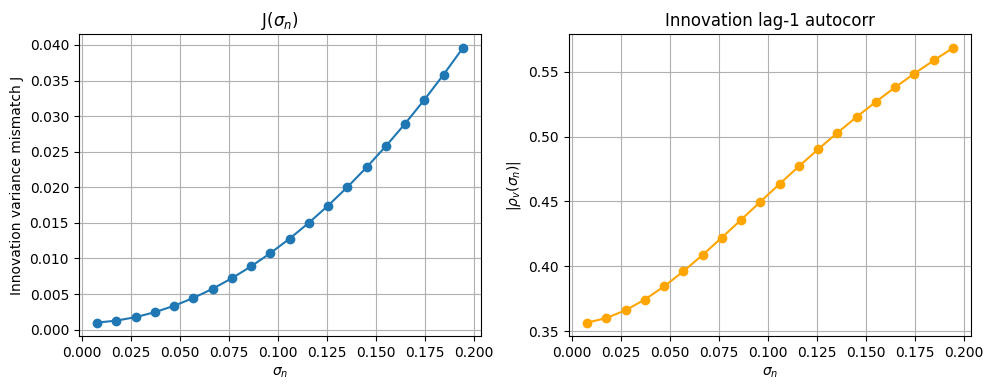

In [56]:
y = g_area_7_list
mu = mu_hat
theta = theta_hat
sigma = sigma2_hat
sigma_n_grid, J_vals, rho_vals = diagnostics_vs_sigma_n(y, dt, mu, theta, sigma)

In [37]:
import numpy as np
from scipy.optimize import minimize

def kalman_loglikelihood(params, y, dt):
    mu, theta, log_sigma, log_sigma_n = params
    sigma = np.exp(log_sigma)
    sigma_n = np.exp(log_sigma_n)

    alpha = np.exp(-theta * dt)
    beta2 = sigma**2 / (2.0 * theta) * (1.0 - np.exp(-2.0 * theta * dt))

    # Initial state: use mean of y and large variance
    g_post = y[0]
    P_post = np.var(y)  # or larger

    loglik = 0.0
    for i in range(1, len(y)):
        # Prediction
        g_prior = alpha * g_post + (1.0 - alpha) * mu
        P_prior = alpha**2 * P_post + beta2

        # Innovation
        v = y[i] - g_prior
        S = P_prior + sigma_n**2

        # Accumulate log-likelihood
        loglik += -0.5 * (np.log(2.0 * np.pi) + np.log(S) + v**2 / S)

        # Update
        K = P_prior / S
        g_post = g_prior + K * v
        P_post = (1.0 - K) * P_prior
    return -loglik

def fit_ou_kalman_mle(y, dt):
    y = np.asarray(y)
    mu0 = np.mean(y)
    theta0 = 1.0 / (10.0 * dt)             # crude guess
    sigma0 = 0.5 * np.std(y)
    sigma_n0 = 0.1 * np.std(y)

    x0 = np.array([mu0, theta0, np.log(sigma0), np.log(sigma_n0)])

    bounds = [
        (None, None),      # mu
        (1e-6, None),      # theta > 0
        (None, None),      # log_sigma
        (None, None)       # log_sigma_n
    ]

    res = minimize(kalman_loglikelihood, x0, args=(y, dt),
                   bounds=bounds, method='L-BFGS-B')

    mu, theta, log_sigma, log_sigma_n = res.x
    sigma = np.exp(log_sigma)
    sigma_n = np.exp(log_sigma_n)

    return {
        "mu": mu,
        "theta": theta,
        "sigma": sigma,
        "sigma_n": sigma_n,
        "opt_result": res,
    }

In [70]:
dt = np.mean(np.diff(time))
dt

np.float64(0.004166666666666667)

In [57]:
fit_ou_kalman_mle(y, dt)

{'mu': np.float64(0.7845462159691249),
 'theta': np.float64(0.6847469764170384),
 'sigma': np.float64(0.4561080228505978),
 'sigma_n': np.float64(2.11583343345869e-05),
 'opt_result':   message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
   success: True
    status: 0
       fun: -143.6113058095389
         x: [ 7.845e-01  6.847e-01 -7.850e-01 -1.076e+01]
       nit: 35
       jac: [-2.136e-02  8.288e-03 -9.773e-02  5.684e-06]
      nfev: 285
      njev: 57
  hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>}

In [58]:
params = fit_ou_kalman_mle(y, dt)
mu_hat     = float(params["mu"])
theta_hat  = float(params["theta"])
sigma_hat  = float(params["sigma"])
sigma_n_hat = float(params["sigma_n"])

print(mu_hat, theta_hat, sigma_hat, sigma_n_hat)

0.7845462159691249 0.6847469764170384 0.4561080228505978 2.11583343345869e-05


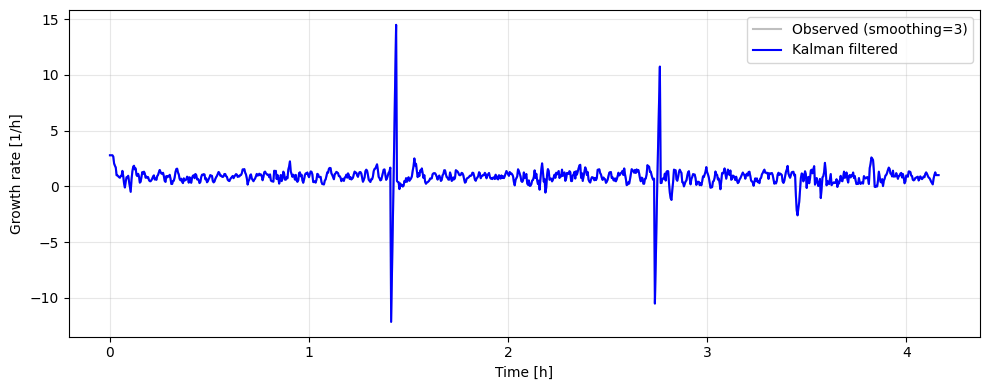

In [71]:
#after kalman likelihood maximization
y = g_length_7_list
N = len(y)
sigma_n = sigma_n_hat     
mu = mu_hat     
theta = theta_hat         
sigma2 = sigma2_hat       
alpha = np.exp(-theta_hat * dt)
beta2 = (sigma2**2 / (2 * theta_hat)) * (1 - np.exp(-2 * theta_hat * dt))
g_filt = np.zeros(N)
P_filt = np.zeros(N)
g_filt[0] = y[0]    # or mu
P_filt[0] = 1.0

for i in range(1, N):
    g_pred = alpha * g_filt[i-1] + (1 - alpha) * mu
    P_pred = alpha**2 * P_filt[i-1] + beta2

    v = y[i] - g_pred                 # innovation
    S = P_pred + sigma_n**2           # innovation variance
    K = P_pred / S                    # Kalman gain

    g_filt[i] = g_pred + K * v        # posterior mean
    P_filt[i] = (1 - K) * P_pred      # posterior variance
plt.figure(figsize=(10,4))
plt.plot(time, y, color='gray', alpha=0.5, label='Observed (smoothing=3)')
plt.plot(time, g_filt, color='blue', label='Kalman filtered')
plt.xlabel('Time [h]')
plt.ylabel('Growth rate [1/h]')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [73]:
#simulated data
#noisy
#getting estimates after kalman likelihood maximization on noisy
#KF on two measurements
#optimizng by one parameter at a time